<a href="https://colab.research.google.com/github/GuilleeSS/MyRepo/blob/main/Lab2NM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np

# List of numeric precision types to test
types_list = [np.float16, np.float32, np.float64, np.float128]

def find_precision_limit(number_type):
    print(f"--- Checking {number_type.__name__} ---")

    exponent = 0
    while exponent < 150:
        # Compute epsilon as 2^(-exponent)
        eps = number_type(2.0) ** number_type(-exponent)

        # Add epsilon to 1
        result = number_type(1.0) + eps

        # Check when adding epsilon no longer changes the value
        if result == number_type(1.0):
            print(f"Precision limit reached at n = {exponent}")
            print(f"So 1 + (1 / 2^{exponent}) equals 1 in this precision.")
            return

        exponent += 1

    # If no precision loss is detected within the range
    print("No precision loss found in range.\n")


# Run the test for each precision type
for t in types_list:
    find_precision_limit(t)
    print()

--- Checking float16 ---
Precision limit reached at n = 11
So 1 + (1 / 2^11) equals 1 in this precision.

--- Checking float32 ---
Precision limit reached at n = 24
So 1 + (1 / 2^24) equals 1 in this precision.

--- Checking float64 ---
Precision limit reached at n = 53
So 1 + (1 / 2^53) equals 1 in this precision.

--- Checking longdouble ---
Precision limit reached at n = 64
So 1 + (1 / 2^64) equals 1 in this precision.



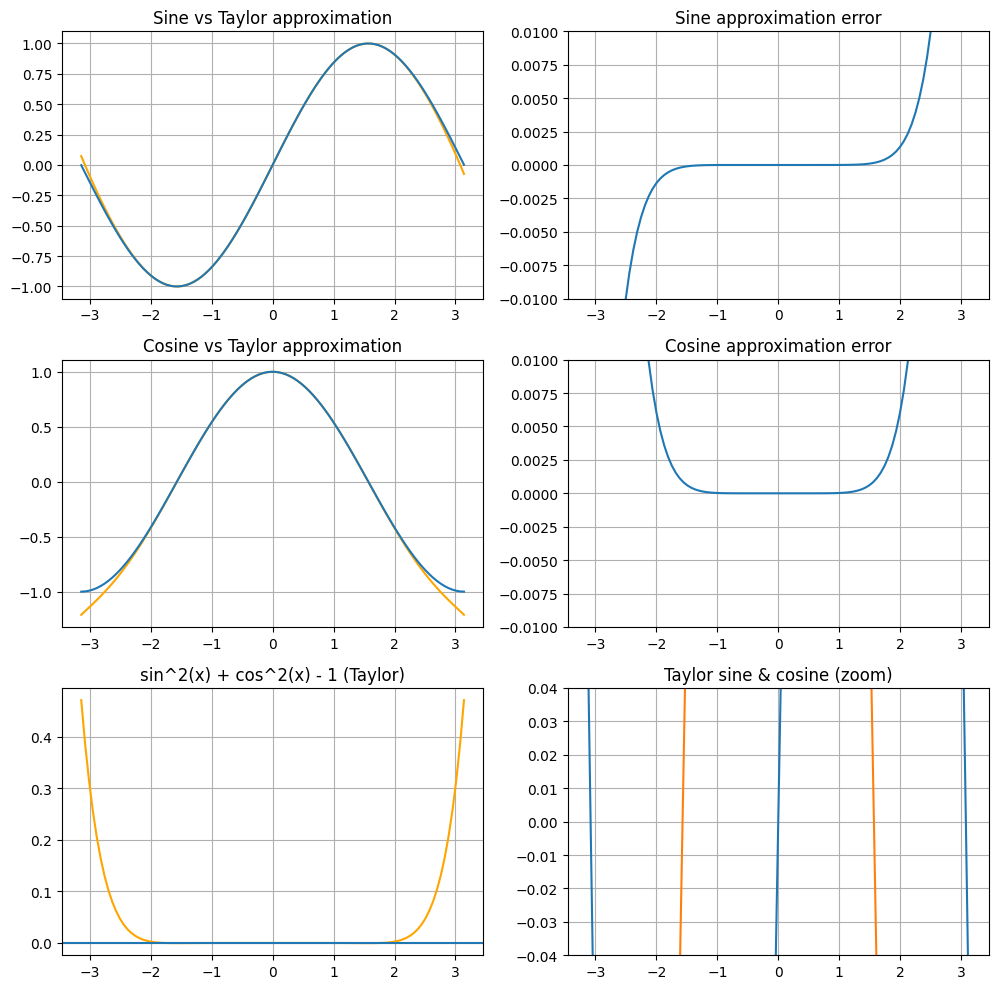

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Function to compute Taylor expansion for sine
def sin_series(x, n_terms=5):
    total = 0
    k = 0
    while k < n_terms:
        total += ((-1)**k * x**(2*k + 1)) / math.factorial(2*k + 1)
        k += 1
    return total

# Function to compute Taylor expansion for cosine
def cos_series(x, n_terms=5):
    total = 0
    k = 0
    while k < n_terms:
        total += ((-1)**k * x**(2*k)) / math.factorial(2*k)
        k += 1
    return total

# Generate values in the interval [-pi, pi]
values = np.linspace(-3.14, 3.14, 100)

# Reference values using NumPy
real_sin = np.sin(values)
real_cos = np.cos(values)

# Taylor approximations (limited number of terms)
approx_sin = sin_series(values, n_terms=4)
approx_cos = cos_series(values, n_terms=4)

# Create figure with 3 rows and 2 columns
figure, grid = plt.subplots(3, 2, figsize=(10, 10))

# --- Plot 1: Sine comparison ---
grid[0, 0].plot(values, approx_sin, label="Taylor", color="orange")
grid[0, 0].plot(values, real_sin, label="NumPy")
grid[0, 0].set_title("Sine vs Taylor approximation")
grid[0, 0].grid(True)

# --- Plot 2: Error in sine ---
error_sin = real_sin - approx_sin
grid[0, 1].plot(values, error_sin)
grid[0, 1].set_title("Sine approximation error")
grid[0, 1].set_ylim(-0.01, 0.01)
grid[0, 1].grid(True)

# --- Plot 3: Cosine comparison ---
grid[1, 0].plot(values, approx_cos, label="Taylor", color="orange")
grid[1, 0].plot(values, real_cos, label="NumPy")
grid[1, 0].set_title("Cosine vs Taylor approximation")
grid[1, 0].grid(True)

# --- Plot 4: Error in cosine ---
error_cos = real_cos - approx_cos
grid[1, 1].plot(values, error_cos)
grid[1, 1].set_title("Cosine approximation error")
grid[1, 1].set_ylim(-0.01, 0.01)
grid[1, 1].grid(True)

# --- Plot 5: Trigonometric identity check ---
identity_check = approx_sin**2 + approx_cos**2 - 1
grid[2, 0].plot(values, identity_check, color="orange")
grid[2, 0].axhline(0)  # Horizontal line at y = 0
grid[2, 0].set_title("sin^2(x) + cos^2(x) - 1 (Taylor)")
grid[2, 0].grid(True)

# --- Plot 6: Zoomed Taylor functions ---
grid[2, 1].plot(values, approx_sin)
grid[2, 1].plot(values, approx_cos)
grid[2, 1].set_title("Taylor sine & cosine (zoom)")
grid[2, 1].set_ylim(-0.04, 0.04)
grid[2, 1].grid(True)

# Adjust layout and display
plt.tight_layout()
plt.show()